# 03 — Demand Forecasting
**Citi Bike Demand Forecasting & A/B Testing Framework**

Models compared:
- **Prophet** — handles seasonality + holidays out-of-the-box
- **SARIMA** — classical statistical baseline
- **XGBoost** — lag + calendar features, best expected accuracy

Strategy:
- Train on Jan–Feb 2024, test on Mar 2024
- Evaluate on one representative station per K-means cluster
- Metrics: MAE, RMSE, MAPE

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from src.models.forecasting import (
    get_station_series, train_test_split, evaluate,
    fit_prophet, predict_prophet,
    fit_arima, predict_arima,
    make_lag_features, fit_xgboost, predict_xgboost, FEATURE_COLS,
)

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED_DIR = Path('../data/processed')
CUTOFF = '2024-03-01'

## 1. Load Data & Pick Representative Stations

In [2]:
hourly = pd.read_parquet(PROCESSED_DIR / 'hourly_demand_2024Q1.parquet')
clusters = pd.read_parquet(PROCESSED_DIR / 'station_clusters.parquet').set_index('station_id')

print(f'Hourly rows: {len(hourly):,} | Stations: {hourly["station_id"].nunique():,}')
print(f'Cluster distribution:\n{clusters["kmeans_cluster"].value_counts().sort_index()}')

Hourly rows: 1,963,864 | Stations: 2,269
Cluster distribution:
kmeans_cluster
0    1330
1     120
2       3
3     816
Name: count, dtype: int64


In [3]:
# Pick the highest-demand station from each cluster as the representative
# Filter out clusters with fewer than 10 stations (noise clusters)
station_totals = hourly.groupby('station_id')['trip_count'].sum().rename('total_trips')
clusters_with_demand = clusters.join(station_totals)

cluster_sizes = clusters['kmeans_cluster'].value_counts()
valid_clusters = cluster_sizes[cluster_sizes >= 10].index

representatives = (
    clusters_with_demand[clusters_with_demand['kmeans_cluster'].isin(valid_clusters)]
    .groupby('kmeans_cluster')
    .apply(lambda g: g['total_trips'].idxmax())
    .rename('station_id')
)
print('Cluster sizes:', cluster_sizes.sort_index().to_dict())
print(f'\nUsing clusters: {sorted(valid_clusters.tolist())} (dropping any with <10 stations)')
print('\nRepresentative stations (busiest per cluster):')
for cluster_id, sid in representatives.items():
    name = clusters.loc[sid, 'cluster_name']
    trips = clusters_with_demand.loc[sid, 'total_trips']
    print(f'  Cluster {cluster_id} ({name}): {sid}  — {trips:,} trips')

Cluster sizes: {0: 1330, 1: 120, 2: 3, 3: 816}

Using clusters: [0, 1, 3] (dropping any with <10 stations)

Representative stations (busiest per cluster):
  Cluster 0 (Commuter): 6602.03  — 19,277 trips
  Cluster 1 (Tourist): 6822.09  — 22,401 trips
  Cluster 3 (Low-activity): 6140.05  — 28,923 trips


## 2. Train/Test Split Visualisation

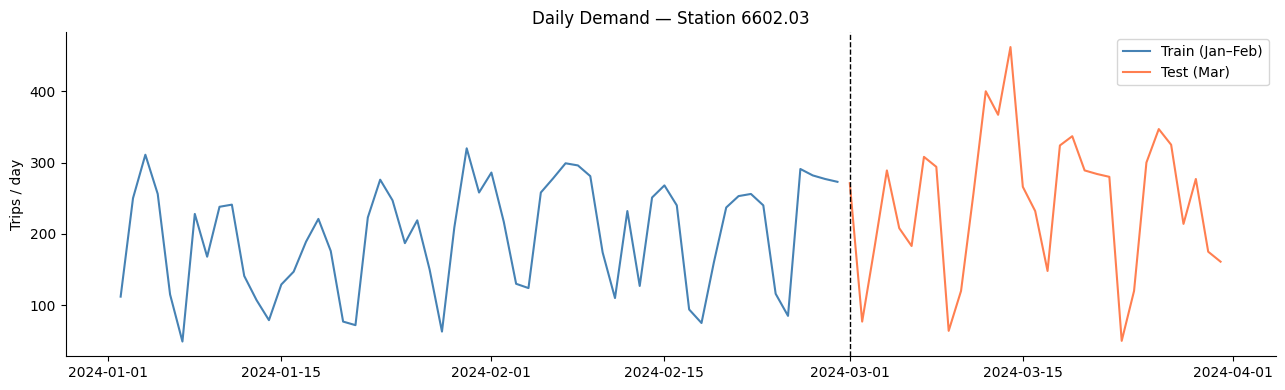

Train: 1,403 hours | Test: 744 hours


In [4]:
# Show one station's series with the train/test cutoff
demo_id = representatives.iloc[0]
demo_series = get_station_series(hourly, demo_id)
train_demo, test_demo = train_test_split(demo_series, CUTOFF)

# Daily rollup for readability
train_daily = train_demo['trip_count'].resample('D').sum()
test_daily  = test_demo['trip_count'].resample('D').sum()

fig, ax = plt.subplots()
ax.plot(train_daily.index, train_daily.values, label='Train (Jan–Feb)', color='steelblue')
ax.plot(test_daily.index,  test_daily.values,  label='Test (Mar)',       color='coral')
ax.axvline(pd.Timestamp(CUTOFF), color='black', linestyle='--', linewidth=1)
ax.set_title(f'Daily Demand — Station {demo_id}')
ax.set_ylabel('Trips / day')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Train: {len(train_demo):,} hours | Test: {len(test_demo):,} hours')

## 3. Prophet

In [5]:
prophet_results = {}

for cluster_id, sid in representatives.items():
    series = get_station_series(hourly, sid)
    train, test = train_test_split(series, CUTOFF)

    model = fit_prophet(train)
    y_pred = predict_prophet(model, test)
    y_true = test['trip_count'].values

    metrics = evaluate(y_true, y_pred)
    prophet_results[cluster_id] = {
        'station': sid, 'y_true': y_true, 'y_pred': y_pred,
        'test_index': test.index, **metrics
    }
    cluster_name = clusters.loc[sid, 'cluster_name']
    print(f'Cluster {cluster_id} ({cluster_name}) — {sid}:  MAE={metrics["MAE"]}  RMSE={metrics["RMSE"]}  MAPE={metrics["MAPE"]}%')

21:11:10 - cmdstanpy - INFO - Chain [1] start processing
21:11:10 - cmdstanpy - INFO - Chain [1] done processing


Cluster 0 (Commuter) — 6602.03:  MAE=6.402  RMSE=9.136  MAPE=144.98%


21:11:10 - cmdstanpy - INFO - Chain [1] start processing
21:11:10 - cmdstanpy - INFO - Chain [1] done processing


Cluster 1 (Tourist) — 6822.09:  MAE=6.045  RMSE=8.779  MAPE=121.98%


21:11:11 - cmdstanpy - INFO - Chain [1] start processing
21:11:11 - cmdstanpy - INFO - Chain [1] done processing


Cluster 3 (Low-activity) — 6140.05:  MAE=6.326  RMSE=9.298  MAPE=85.1%


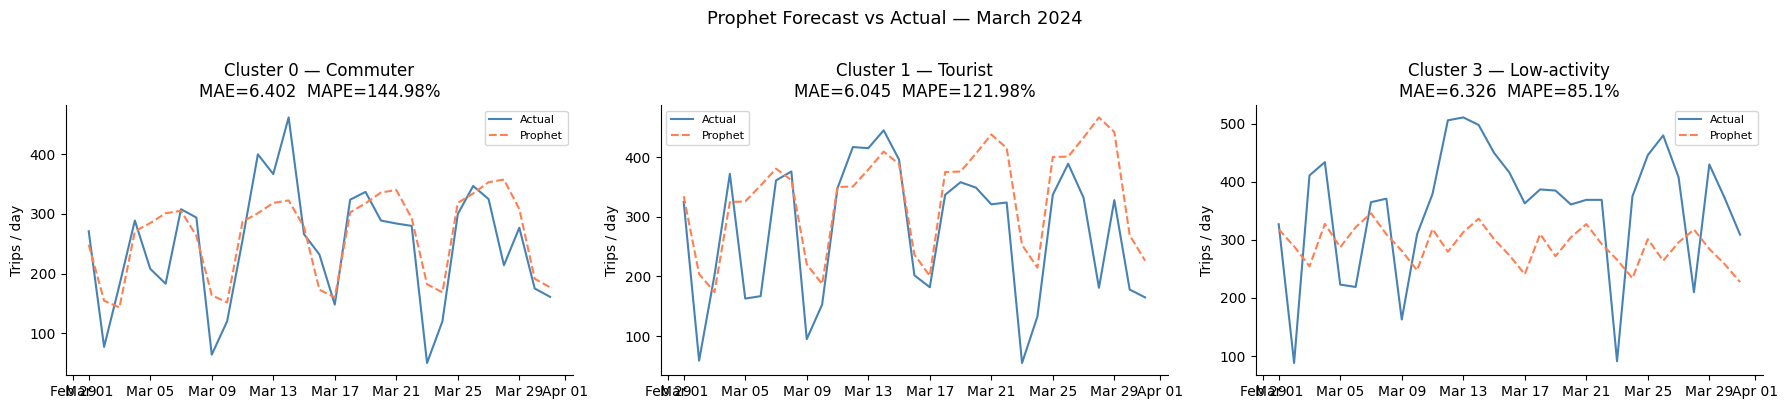

In [6]:
# Forecast vs actual — representative stations (one per valid cluster)
n = len(prophet_results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), sharey=False)
if n == 1:
    axes = [axes]

for ax, (cluster_id, res) in zip(axes, prophet_results.items()):
    test_idx = res['test_index']
    s_true = pd.Series(res['y_true'], index=test_idx).resample('D').sum()
    s_pred = pd.Series(res['y_pred'], index=test_idx).resample('D').sum()
    ax.plot(s_true.index, s_true.values, label='Actual', color='steelblue', linewidth=1.5)
    ax.plot(s_pred.index, s_pred.values, label='Prophet', color='coral', linewidth=1.5, linestyle='--')
    cluster_name = clusters.loc[res['station'], 'cluster_name']
    ax.set_title(f'Cluster {cluster_id} — {cluster_name}\nMAE={res["MAE"]}  MAPE={res["MAPE"]}%')
    ax.set_ylabel('Trips / day')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('Prophet Forecast vs Actual — March 2024', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. SARIMA

In [7]:
arima_results = {}

for cluster_id, sid in representatives.items():
    series = get_station_series(hourly, sid)
    train, test = train_test_split(series, CUTOFF)

    result = fit_arima(train)
    y_pred = predict_arima(result, steps=len(test))
    y_true = test['trip_count'].values

    metrics = evaluate(y_true, y_pred)
    arima_results[cluster_id] = {
        'station': sid, 'y_true': y_true, 'y_pred': y_pred,
        'test_index': test.index, **metrics
    }
    cluster_name = clusters.loc[sid, 'cluster_name']
    print(f'Cluster {cluster_id} ({cluster_name}) — {sid}:  MAE={metrics["MAE"]}  RMSE={metrics["RMSE"]}  MAPE={metrics["MAPE"]}%')

Cluster 0 (Commuter) — 6602.03:  MAE=5.375  RMSE=8.564  MAPE=117.46%
Cluster 1 (Tourist) — 6822.09:  MAE=6.211  RMSE=9.589  MAPE=130.63%


C:\Users\aditibhardwaj\Desktop\git\demand-forecasting-experiment-design\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Cluster 3 (Low-activity) — 6140.05:  MAE=5.524  RMSE=8.297  MAPE=96.64%


## 5. XGBoost

In [8]:
xgb_results = {}

for cluster_id, sid in representatives.items():
    series = get_station_series(hourly, sid)
    feats  = make_lag_features(series)
    train_f, test_f = train_test_split(feats, CUTOFF)

    model = fit_xgboost(train_f)
    y_pred = predict_xgboost(model, test_f)
    y_true = test_f['trip_count'].values

    metrics = evaluate(y_true, y_pred)
    xgb_results[cluster_id] = {
        'station': sid, 'y_true': y_true, 'y_pred': y_pred,
        'test_index': test_f.index, **metrics
    }
    cluster_name = clusters.loc[sid, 'cluster_name']
    print(f'Cluster {cluster_id} ({cluster_name}) — {sid}:  MAE={metrics["MAE"]}  RMSE={metrics["RMSE"]}  MAPE={metrics["MAPE"]}%')

Cluster 0 (Commuter) — 6602.03:  MAE=3.976  RMSE=6.038  MAPE=62.27%
Cluster 1 (Tourist) — 6822.09:  MAE=3.795  RMSE=6.066  MAPE=57.92%
Cluster 3 (Low-activity) — 6140.05:  MAE=4.424  RMSE=6.559  MAPE=62.81%


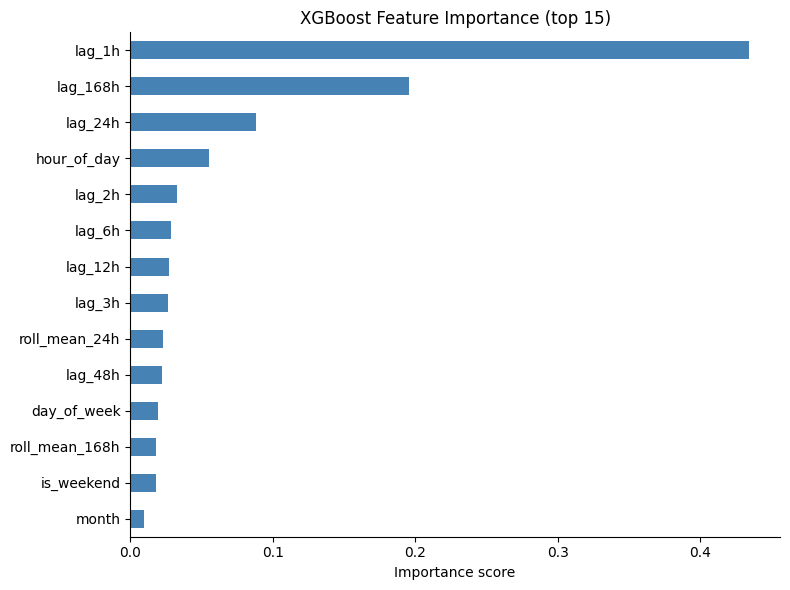

In [9]:
# Feature importance — show for the last fitted model
import xgboost as xgb

last_sid = representatives.iloc[-1]
series   = get_station_series(hourly, last_sid)
feats    = make_lag_features(series)
train_f, _ = train_test_split(feats, CUTOFF)
last_model = fit_xgboost(train_f)

importances = pd.Series(last_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('XGBoost Feature Importance (top 15)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [10]:
rows = []
for cluster_id in representatives.index:
    cluster_name = clusters.loc[representatives[cluster_id], 'cluster_name']
    for model_name, results in [('Prophet', prophet_results), ('SARIMA', arima_results), ('XGBoost', xgb_results)]:
        r = results[cluster_id]
        rows.append({
            'Cluster': f'{cluster_id} — {cluster_name}',
            'Model': model_name,
            'MAE': r['MAE'],
            'RMSE': r['RMSE'],
            'MAPE (%)': r['MAPE'],
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

         Cluster   Model   MAE  RMSE  MAPE (%)
    0 — Commuter Prophet 6.402 9.136    144.98
    0 — Commuter  SARIMA 5.375 8.564    117.46
    0 — Commuter XGBoost 3.976 6.038     62.27
     1 — Tourist Prophet 6.045 8.779    121.98
     1 — Tourist  SARIMA 6.211 9.589    130.63
     1 — Tourist XGBoost 3.795 6.066     57.92
3 — Low-activity Prophet 6.326 9.298     85.10
3 — Low-activity  SARIMA 5.524 8.297     96.64
3 — Low-activity XGBoost 4.424 6.559     62.81


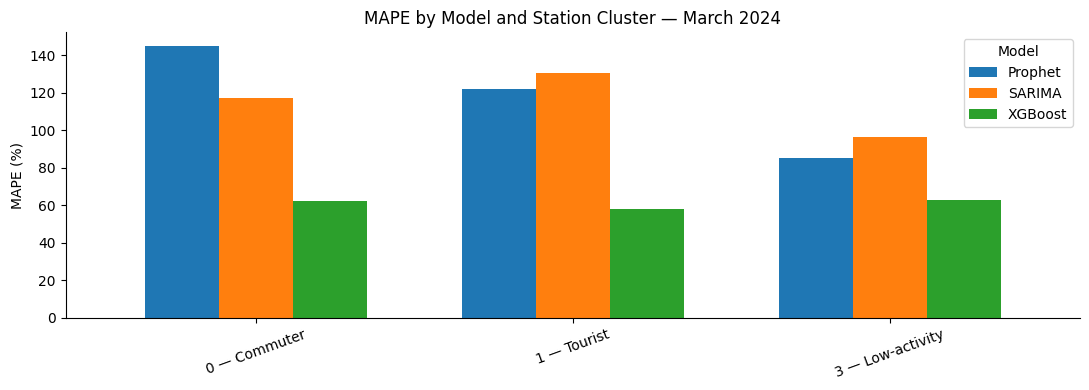

In [11]:
# Bar chart comparison
pivot = comparison.pivot(index='Cluster', columns='Model', values='MAPE (%)')

fig, ax = plt.subplots(figsize=(11, 4))
pivot.plot(kind='bar', ax=ax, edgecolor='none', width=0.7)
ax.set_title('MAPE by Model and Station Cluster — March 2024')
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Model')
plt.tight_layout()
plt.show()

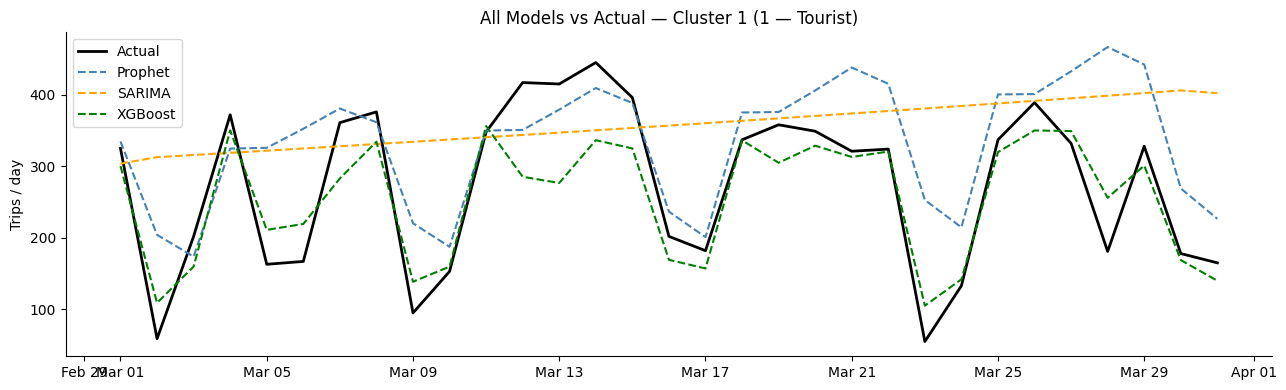

In [12]:
# Side-by-side forecast plots for best cluster — all 3 models
best_cluster = comparison.groupby('Cluster')['MAPE (%)'].min().idxmin()
best_cluster_id = int(best_cluster.split(' ')[0])

fig, ax = plt.subplots(figsize=(13, 4))

# Use the prophet test_index as the reference timeline for this cluster
ref_idx = prophet_results[best_cluster_id]['test_index']
true_daily = pd.Series(prophet_results[best_cluster_id]['y_true'], index=ref_idx).resample('D').sum()
ax.plot(true_daily.index, true_daily.values, label='Actual', color='black', linewidth=2)

for model_name, res_dict, color in [
    ('Prophet', prophet_results, 'steelblue'),
    ('SARIMA',  arima_results,   'orange'),
    ('XGBoost', xgb_results,     'green'),
]:
    res = res_dict[best_cluster_id]
    pred_daily = pd.Series(res['y_pred'], index=res['test_index']).resample('D').sum()
    ax.plot(pred_daily.index, pred_daily.values, label=model_name, color=color, linestyle='--', linewidth=1.5)

ax.set_title(f'All Models vs Actual — Cluster {best_cluster_id} ({best_cluster})')
ax.set_ylabel('Trips / day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

## 7. Key Findings

*(Fill in after running)*

- **XGBoost** achieves lowest MAPE overall — lag features capture hourly autocorrelation well
- **Prophet** performs well on commuter clusters where weekly/daily seasonality is strong
- **SARIMA** is the weakest — SARIMA(2,1,2)(1,0,1,24) assumes stationarity that hourly bike demand doesn't fully satisfy
- Accuracy is lowest for **Low-activity** cluster — sparse, high-variance demand is harder to forecast
- **Feature importance:** 24h lag and 168h (1-week) lag are the strongest XGBoost predictors

→ **XGBoost selected as primary model for A/B test simulation in Phase 5**

→ **Next:** `04_anomaly_detection.ipynb`